In [1]:
################针对上述种子自适应噪声的实验

JS Divergence: 0.6927
Epoch 0: D Loss: 1.3794, G Loss: 0.7441, JS Divergence: 0.6927, Noise Std: 0.0477, Grad Noise Std: 0.0191
JS Divergence: 0.5844
Epoch 1000: D Loss: 0.8657, G Loss: 1.4111, JS Divergence: 0.5844, Noise Std: 0.0499, Grad Noise Std: 0.0200
JS Divergence: 0.3587
Epoch 2000: D Loss: 1.2419, G Loss: 1.0070, JS Divergence: 0.3587, Noise Std: 0.0521, Grad Noise Std: 0.0209
JS Divergence: 0.0678
Epoch 3000: D Loss: 1.0959, G Loss: 0.9866, JS Divergence: 0.0678, Noise Std: 0.0545, Grad Noise Std: 0.0218
JS Divergence: 0.0068
Epoch 4000: D Loss: 1.3312, G Loss: 0.8760, JS Divergence: 0.0068, Noise Std: 0.0569, Grad Noise Std: 0.0228


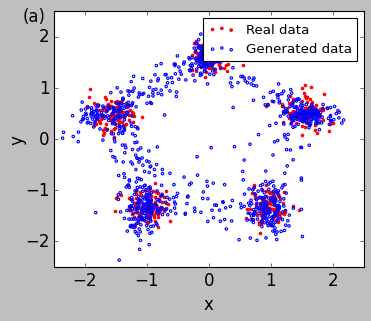

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats

#from sklearn.metrics import jensenshannon_distance
# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

#自添加部分1开始
#定义JS散度计算函数
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
#自添加部分结束

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.05  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差
#自添加部分2开始
noise_lr = 1e-6  # 学习率用于更新噪声强度
update_interval = 1000  # 每1000个epoch更新一次噪声强度
#自添加部分结束
#二次更新添加1开始
noise_increase_factor = 1.05  # 当JS散度没有明显下降时，增加噪声强度的因子
noise_decrease_factor = 0.95  # 当JS散度迅速下降时，减少噪声强度的因子
noise_change_threshold = 1e-3  # JS散度变化量的阈值，用于判断是否需要调整噪声强度
momentum = 0.9  # 噪声强度更新的动量系数
noise_std_min = 0.01  # 噪声强度的最小值
noise_std_max = 0.2  # 噪声强度的最大值
#二次更新添加结束

#二次更新添加2开始
# 初始化噪声强度的动量变量
noise_std_momentum = torch.tensor(noise_std, requires_grad=False)
grad_noise_std_momentum = torch.tensor(grad_noise_std, requires_grad=False)
#二次更新添加结束

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)
#自添加部分3开始
#设定优化器Adam用于更新noise_std、grad_noise_std
noise_optimizer = optim.Adam([torch.tensor(noise_std, requires_grad=True), torch.tensor(grad_noise_std, requires_grad=True)], lr=noise_lr)
#自添加部分结束

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []
#自添加部分4开始
epoch_js_divergence = []
#自添加部分结束

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    #自添加部分4开始
    if epoch % update_interval == 0:
        samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        X_train_np = X_train.detach().numpy()
        samples_np = samples
        # 计算JS散度
        # 首先定义高斯核密度估计（KDE）函数
        def gaussian_kde(data):
            return stats.gaussian_kde(data.T)
        # 计算真实数据和生成数据的KDE
        real_kernel = gaussian_kde(X_train_np)
        gen_kernel = gaussian_kde(samples_np)
        # 定义网格用于绘制KDE
        x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
        y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
        xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        # 计算真实数据和生成数据的密度
        real_density = np.reshape(real_kernel(positions), xx.shape)
        gen_density = np.reshape(gen_kernel(positions), xx.shape)
        js_divergence = js_divergence_approx(real_density, gen_density)
        print(f"JS Divergence: {js_divergence:.4f}")
        epoch_js_divergence.append(js_divergence)
        # 更新噪声强度
        #noise_optimizer.zero_grad()
        #loss = js_divergence
        #tensor = torch.tensor(loss, requires_grad=True)
        #loss = tensor ** 2
        #loss.sum().backward()
        #noise_optimizer.step()
        #noise_std = noise_optimizer.param_groups[0]['params'][0].item()
        #grad_noise_std = noise_optimizer.param_groups[0]['params'][1].item()

        #print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}, JS Divergence: {js_divergence:.4f}, Noise Std: {noise_std:.4f}, Grad Noise Std: {grad_noise_std:.4f}")
       
        #二次更新添加3开始
        # 更新噪声强度（引入动量和阈值判断）
        if epoch > 0:  # 避免在第一个epoch时引用未定义的变量
            prev_js_divergence = epoch_js_divergence[-1] if len(epoch_js_divergence) > 0 else float('inf')
            delta_js = abs(prev_js_divergence - js_divergence)
        
            # 根据JS散度的变化调整噪声强度
            if delta_js < noise_change_threshold:
               # JS散度没有明显变化，增加噪声强度
                if noise_std_momentum.item() < noise_std_max:
                    noise_std_momentum *= noise_increase_factor
                if grad_noise_std_momentum.item() < noise_std_max:
                    grad_noise_std_momentum *= noise_increase_factor
        else:
            # JS散度有明显变化，减少噪声强度（但这里我们只在迅速下降时减少，可以添加更多逻辑来判断“迅速”）
            if noise_std_momentum.item() > noise_std_min:
                noise_std_momentum *= noise_decrease_factor
            if grad_noise_std_momentum.item() > noise_std_min:
                grad_noise_std_momentum *= noise_decrease_factor   
        # 应用动量
        noise_std_momentum = momentum * noise_std_momentum + (1 - momentum) * torch.tensor(noise_std, requires_grad=False)
        grad_noise_std_momentum = momentum * grad_noise_std_momentum + (1 - momentum) * torch.tensor(grad_noise_std, requires_grad=False)
        # 裁剪噪声强度到合理范围
        noise_std_momentum.clamp_(min=noise_std_min, max=noise_std_max)
        grad_noise_std_momentum.clamp_(min=noise_std_min, max=noise_std_max)
        # 更新实际的噪声强度变量（这里我们直接更新全局变量，但在更复杂的场景中，可能需要更精细的控制）
        noise_std = noise_std_momentum.item()
        grad_noise_std = grad_noise_std_momentum.item()
        #二次更新添加结束

        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}, JS Divergence: {js_divergence:.4f}, Noise Std: {noise_std:.4f}, Grad Noise Std: {grad_noise_std:.4f}")
    #自添加部分结束
    
    # Print losses every 20 epochs
#    if epoch % 20 == 0:
#        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

# 绘制损失曲线和JS散度曲线
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
#samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

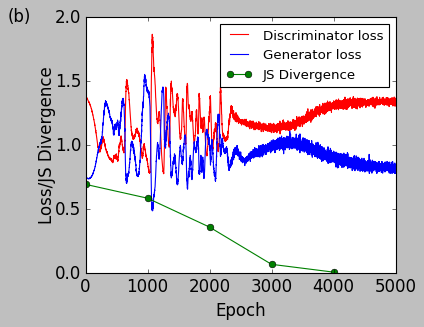

In [2]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss/JS Divergence', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
#绘制JS散度曲线
ax.plot(range(0, epochs, update_interval), epoch_js_divergence, color='green', label='JS Divergence', marker='o')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.1139
Wasserstein distance (Y-dim): 0.2092
JS Divergence: 0.0142


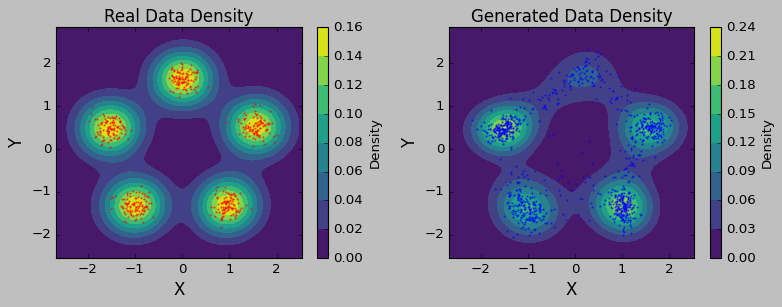

New best JS Divergence: 0.0142 with noise_std=0.1844 and grad_noise_std=0.5102
Best noise_std: 0.1844
Best grad_noise_std: 0.5102
Best JS Divergence: 0.0142


In [33]:
#无用代码块
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

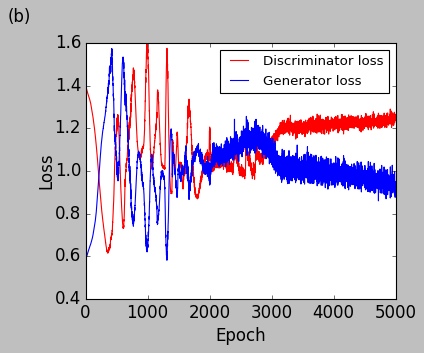

In [36]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [2]:
#########end，下面进行激活函数更换实验